# Data Dive
# Data analysis on Nashville Airbnb Data
### By Wasim Raja Mondal

<a id="99"></a>


<b>Program Sections</b>
<ul>
<li><a href = "#0"> 1 Code directory structure  </a></li>
<li><a href = "#1"> 2 Import Liabraries </a></li>
<li><a href = "#2"> 3 Import Data</a></li> 
<li><a href = "#3"> 4 Data Preprocessing </a></li> 
<li><a href = "#4"> 5 Data Visulalization</a></li>
<li><a href = "#5"> 6 Model </a></li>

### 1. Code directory Structure

In [1]:
!ls data

amenitiesdummies_top87.csv listings.csv.gz
cal_listings.csv.gz        listings_review.csv.gz
calendar.csv.gz            reviews.csv.gz
hosts.csv


### 2 Import Libraries

In [2]:
!pip install numpy #installing numpy
!pip install pandas #installing pandas
!pip install matplotlib #installing matplotlib
!pip install seaborn #installing seaborn
!pip install statsmodels #installing statmodel
!pip install scikit-learn #installing scikit learn
import numpy as np  #importing numpy
import pandas as pd #importing pandas
import seaborn as sns #importing seaborn
import pandas as pd #importing pandas
import statsmodels  #importing statmodels
import statsmodels.api as sm
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500) #allows for up to 500 columns to be displayed when viewing a dataframe
plt.style.use("seaborn-v0_8-whitegrid") ##a style that can be used for plots
import datetime as dt #importing datetime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### 3. Import Data 

In [3]:
df_listings = pd.read_csv('data/listings.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')
df_listings_review = pd.read_csv('data/listings_review.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')
df_reviews = pd.read_csv('data/reviews.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')
df_cal_listings = pd.read_csv('data/cal_listings.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')

/var/folders/p1/pwvyyzw90ms7kks3m6v5fy940000gn/T/ipykernel_910/1470554104.py:4: DtypeWarning: Columns (6,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_cal_listings = pd.read_csv('data/cal_listings.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')


In [4]:
df_listings.info(max_cols=100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6144 entries, 0 to 6143
Data columns (total 74 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6144 non-null   int64  
 1   listing_url                                   6144 non-null   object 
 2   scrape_id                                     6144 non-null   int64  
 3   last_scraped                                  6144 non-null   object 
 4   name                                          6144 non-null   object 
 5   description                                   6079 non-null   object 
 6   neighborhood_overview                         4599 non-null   object 
 7   picture_url                                   6144 non-null   object 
 8   host_id                                       6144 non-null   int64  
 9   host_url                                      6144 non-null   o

In [5]:
df_listings_review.info(max_cols=200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5122 entries, 0 to 5121
Data columns (total 197 columns):
 #    Column                                        Non-Null Count  Dtype  
---   ------                                        --------------  -----  
 0    listing_id                                    5122 non-null   int64  
 1    name                                          5122 non-null   object 
 2    description                                   5101 non-null   object 
 3    host_id                                       5122 non-null   int64  
 4    host_name                                     5116 non-null   object 
 5    host_since                                    5122 non-null   float64
 6    host_response_rate                            4397 non-null   object 
 7    host_acceptance_rate                          4795 non-null   object 
 8    host_is_superhost                             5122 non-null   int64  
 9    host_neighbourhood                            2237

In [6]:
df_reviews.info(max_cols=10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262469 entries, 0 to 262468
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   listing_id     262469 non-null  int64 
 1   id             262469 non-null  int64 
 2   date           262469 non-null  object
 3   reviewer_id    262469 non-null  int64 
 4   reviewer_name  262469 non-null  object
 5   comments       262339 non-null  object
dtypes: int64(3), object(3)
memory usage: 12.0+ MB


In [7]:
df_calendar = pd.read_csv('data/calendar.csv.gz', compression='gzip', index_col=None, header=0, sep=',', quotechar='"')

In [8]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2242782 entries, 0 to 2242781
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 119.8+ MB


In [9]:
df_hosts = pd.read_csv('data/hosts.csv', index_col=None, header=0)
df_amenitiesdummies_top87 = pd.read_csv('data/amenitiesdummies_top87.csv', index_col=None, header=0)

In [10]:
df_amenitiesdummies_top87.info(max_cols=100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6144 entries, 0 to 6143
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Index                        6144 non-null   int64
 1   Wifi                         6144 non-null   int64
 2   Smokealarm                   6144 non-null   int64
 3   Heating                      6144 non-null   int64
 4   Airconditioning              6144 non-null   int64
 5   TV                           6144 non-null   int64
 6   Essentials                   6144 non-null   int64
 7   Hairdryer                    6144 non-null   int64
 8   Iron                         6144 non-null   int64
 9   Hangers                      6144 non-null   int64
 10  Kitchen                      6144 non-null   int64
 11  Longtermstaysallowed         6144 non-null   int64
 12  Shampoo                      6144 non-null   int64
 13  Freeparkingonpremises        6144 non-null   int

In [11]:
df_hosts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 2917 non-null   int64  
 1   host_name                  2915 non-null   object 
 2   host_since                 2917 non-null   float64
 3   host_response_rate         2181 non-null   object 
 4   host_acceptance_rate       2478 non-null   object 
 5   host_is_superhost          2917 non-null   int64  
 6   host_neighbourhood         711 non-null    object 
 7   host_listings_count        2917 non-null   float64
 8   host_total_listings_count  2917 non-null   float64
 9   host_has_profile_pic       2917 non-null   int64  
 10  host_identity_verified     2917 non-null   int64  
 11  hv_None                    2917 non-null   int64  
 12  hv_email                   2917 non-null   int64  
 13  hv_facebook                2917 non-null   int64

In [12]:
df_cal_listings.info(max_cols=250)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1869716 entries, 0 to 1869715
Data columns (total 222 columns):
 #    Column                                        Dtype  
---   ------                                        -----  
 0    listing_id                                    int64  
 1    name                                          object 
 2    description                                   object 
 3    host_id                                       int64  
 4    host_name                                     object 
 5    host_since                                    float64
 6    host_response_rate                            object 
 7    host_acceptance_rate                          object 
 8    host_is_superhost                             int64  
 9    host_neighbourhood                            object 
 10   host_listings_count                           float64
 11   host_total_listings_count                     float64
 12   host_has_profile_pic                    

In [13]:
df_listings.info(max_cols=74)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6144 entries, 0 to 6143
Data columns (total 74 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6144 non-null   int64  
 1   listing_url                                   6144 non-null   object 
 2   scrape_id                                     6144 non-null   int64  
 3   last_scraped                                  6144 non-null   object 
 4   name                                          6144 non-null   object 
 5   description                                   6079 non-null   object 
 6   neighborhood_overview                         4599 non-null   object 
 7   picture_url                                   6144 non-null   object 
 8   host_id                                       6144 non-null   int64  
 9   host_url                                      6144 non-null   o

In [14]:
df_listings['price'].head(20)

0      $40.00
1      $75.00
2     $103.00
3      $27.00
4      $24.00
5      $31.00
6      $24.00
7      $69.00
8      $82.00
9      $79.00
10    $200.00
11     $95.00
12     $95.00
13     $90.00
14    $104.00
15     $29.00
16    $125.00
17     $95.00
18     $89.00
19    $150.00
Name: price, dtype: object

### 4. Data Preprocessing

#### Here we are first trying to understand what are most controlling factors for price

In [15]:
df_listings["price_clean"] = (
    df_listings["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df_listings["price_clean"].agg(["min", "max"])

min       10.0
max    25000.0
Name: price_clean, dtype: float64

In [17]:
df = df_cal_listings.copy()

pool_stats = df.groupby("am_Pool").agg({
    "price": "mean",
    "review_scores_rating": "mean"
}).reset_index()

pool_stats

,am_Pool,price,review_scores_rating
0,0,195.515395,96.597989
1,1,316.956976,94.516934


### 5. Visualization

- Ameneties, Pool effect

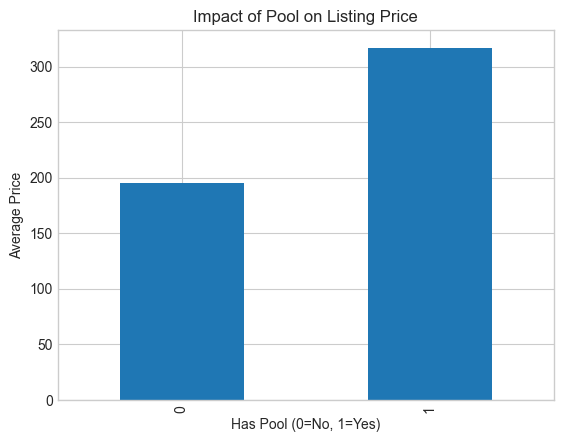

In [18]:
import matplotlib.pyplot as plt

group = df.groupby("am_Pool")["price"].mean()

plt.figure()
group.plot(kind="bar")
plt.xlabel("Has Pool (0=No, 1=Yes)")
plt.ylabel("Average Price")
plt.title("Impact of Pool on Listing Price")
plt.show()

In [19]:
# Select amenity columns
amenity_cols = df.filter(like="am_").columns

# Mean price when amenity = 1
mean_with = df.loc[:, amenity_cols].mul(df["price"], axis=0).sum() / df[amenity_cols].sum()

# Mean price overall
overall_mean = df["price"].mean()

# Mean price when amenity = 0
mean_without = (
    (df["price"].sum() - mean_with * df[amenity_cols].sum())
    / (len(df) - df[amenity_cols].sum())
)

# Price premium
df_price_diff = pd.DataFrame({
    "Amenity": amenity_cols,
    "Price_Premium": (mean_with - mean_without).values
})

df_price_diff = df_price_diff.sort_values(
    "Price_Premium",
    ascending=False
)

df_price_diff.head(10)

,Amenity,Price_Premium
81,am_Crib,248.203223
56,am_Lockonbedroomdoor,222.959684
75,am_EVcharger,178.111167
40,am_Gym,125.312295
39,am_Pool,121.441581
59,am_Highchair,116.068590
4,am_TV,101.417849
30,am_Firstaidkit,77.051642
17,am_Carbonmonoxidealarm,69.865030
0,am_Wifi,62.107093


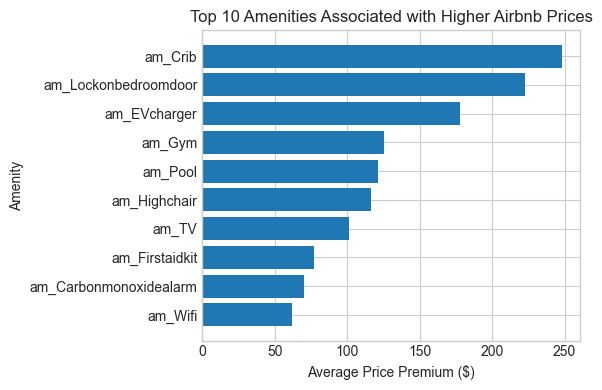

In [20]:
import matplotlib.pyplot as plt

# Select top 10 amenities
top10 = df_price_diff.head(10)

plt.figure(figsize=(6,4))

plt.barh(top10["Amenity"], top10["Price_Premium"])

plt.xlabel("Average Price Premium ($)")
plt.ylabel("Amenity")
plt.title("Top 10 Amenities Associated with Higher Airbnb Prices")

plt.gca().invert_yaxis()   # highest at top
plt.tight_layout()

plt.show()

- Room Type vs Price vs Rating

In [21]:
df = df_cal_listings.copy()

room_cols = [col for col in df.columns if col.startswith("room_")]

# Ensure numeric
df[room_cols] = df[room_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df["Room_Type"] = df[room_cols].idxmax(axis=1)
df["Room_Type"] = df["Room_Type"].str.replace("room_", "", regex=False)

df["Room_Type"].value_counts()

Room_Type
Entire home/apt    1646678
Private room        196024
Hotel room           22267
Shared room           4747
Name: count, dtype: int64

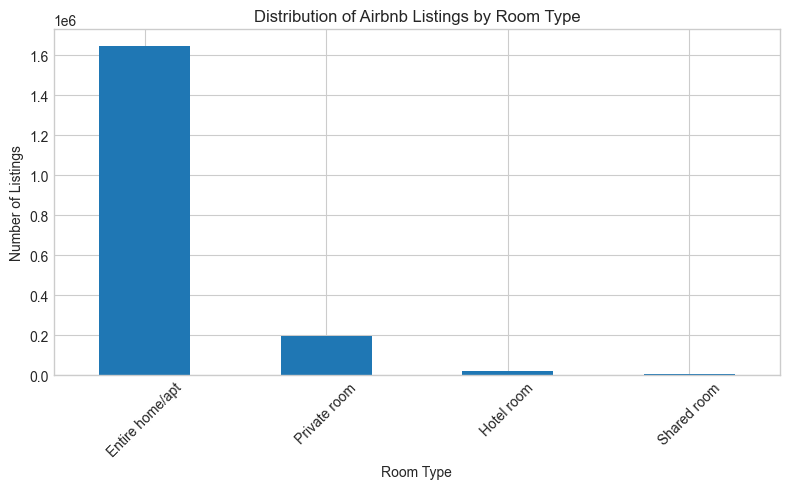

In [22]:
import matplotlib.pyplot as plt

room_counts = df["Room_Type"].value_counts()

plt.figure(figsize=(8,5))
room_counts.plot(kind="bar")

plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Listings by Room Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

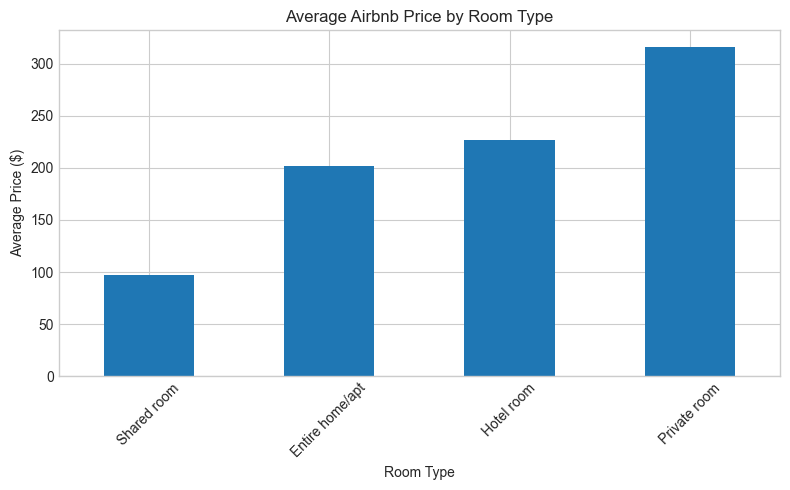

In [23]:
price_by_room = (
    df.groupby("Room_Type")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
price_by_room.plot(kind="bar")

plt.ylabel("Average Price ($)")
plt.xlabel("Room Type")
plt.title("Average Airbnb Price by Room Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

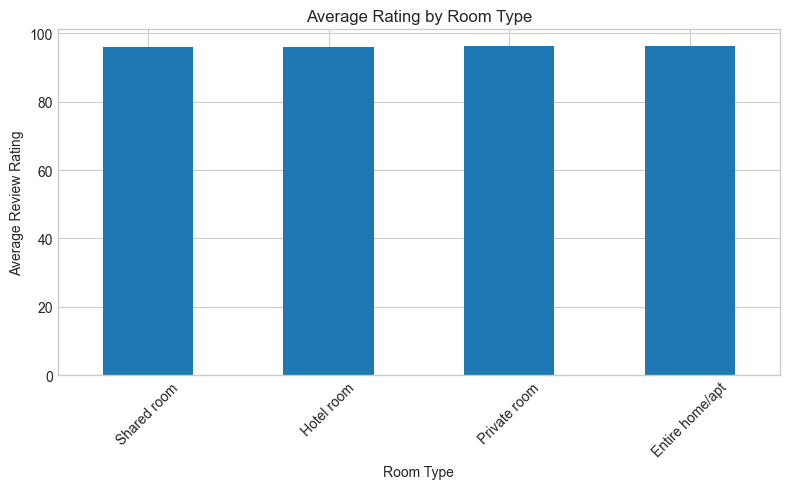

In [24]:
rating_by_room = (
    df.groupby("Room_Type")["review_scores_rating"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
rating_by_room.plot(kind="bar")

plt.ylabel("Average Review Rating")
plt.xlabel("Room Type")
plt.title("Average Rating by Room Type")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

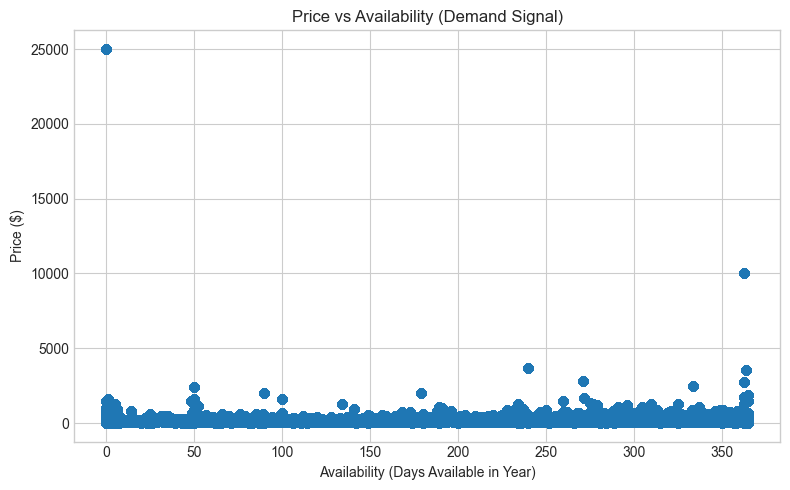

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(df["availability_365"], df["price"], alpha=0.3)

plt.xlabel("Availability (Days Available in Year)")
plt.ylabel("Price ($)")
plt.title("Price vs Availability (Demand Signal)")

plt.tight_layout()
plt.show()

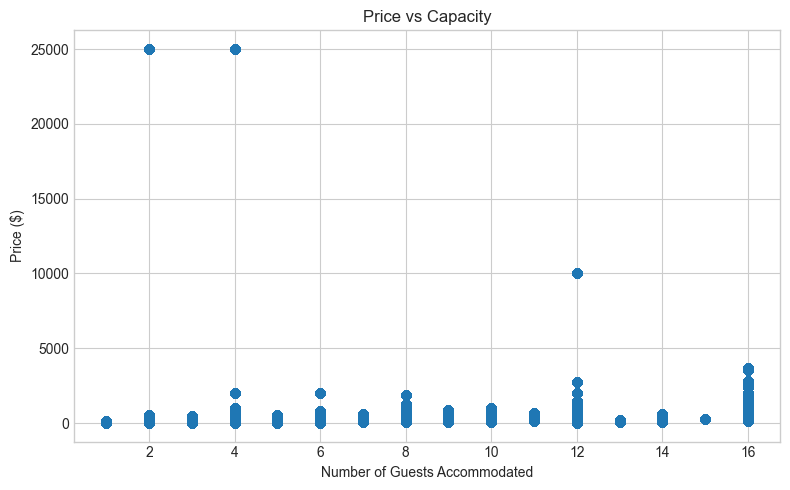

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df["accommodates"], df["price"], alpha=0.3)

plt.xlabel("Number of Guests Accommodated")
plt.ylabel("Price ($)")
plt.title("Price vs Capacity")

plt.tight_layout()
plt.show()

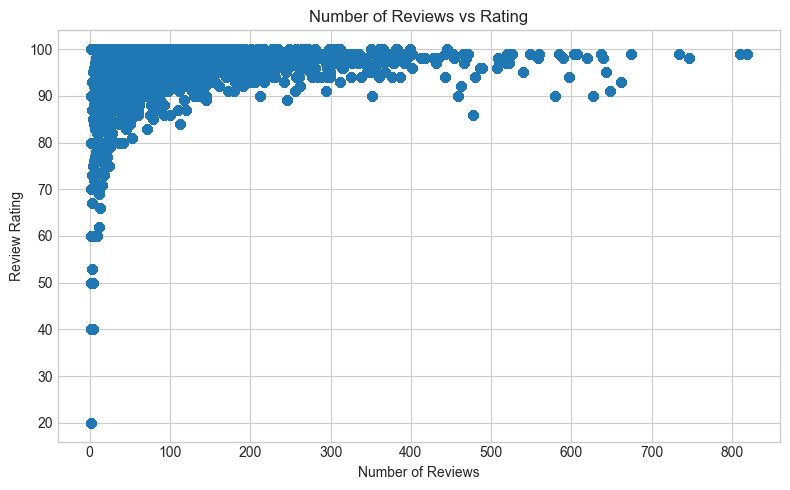

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["number_of_reviews"], 
            df["review_scores_rating"], 
            alpha=0.3)

plt.xlabel("Number of Reviews")
plt.ylabel("Review Rating")
plt.title("Number of Reviews vs Rating")

plt.tight_layout()
plt.show()

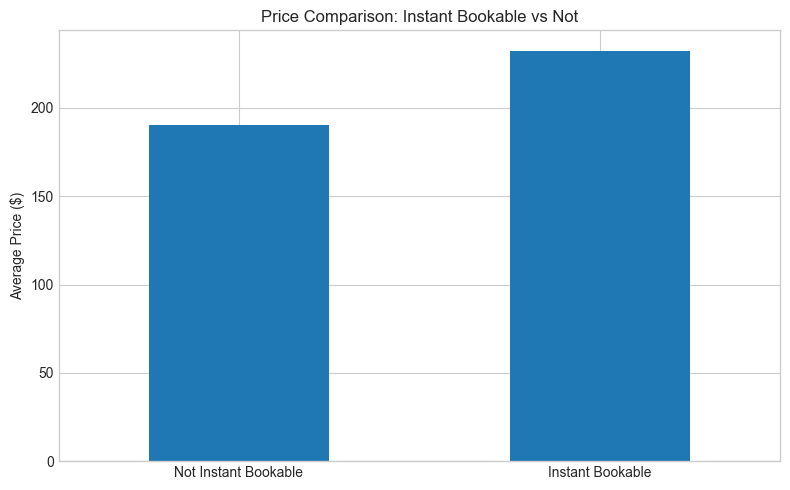

In [28]:
summary = df.groupby("instant_bookable")["price"].mean()

summary.index = ["Not Instant Bookable", "Instant Bookable"]

plt.figure(figsize=(8,5))
summary.plot(kind="bar")

plt.ylabel("Average Price ($)")
plt.title("Price Comparison: Instant Bookable vs Not")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

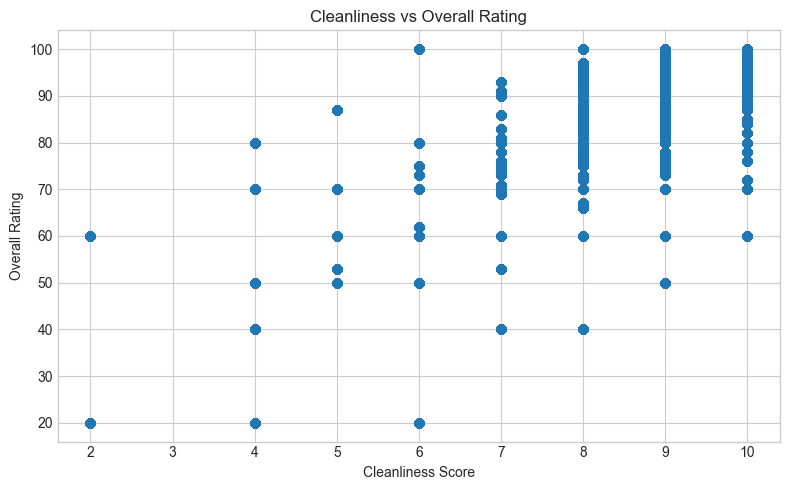

In [29]:
#What Drives Overall Rating?
plt.figure(figsize=(8,5))

plt.scatter(df["review_scores_cleanliness"], 
            df["review_scores_rating"], 
            alpha=0.3)

plt.xlabel("Cleanliness Score")
plt.ylabel("Overall Rating")
plt.title("Cleanliness vs Overall Rating")

plt.tight_layout()
plt.show()

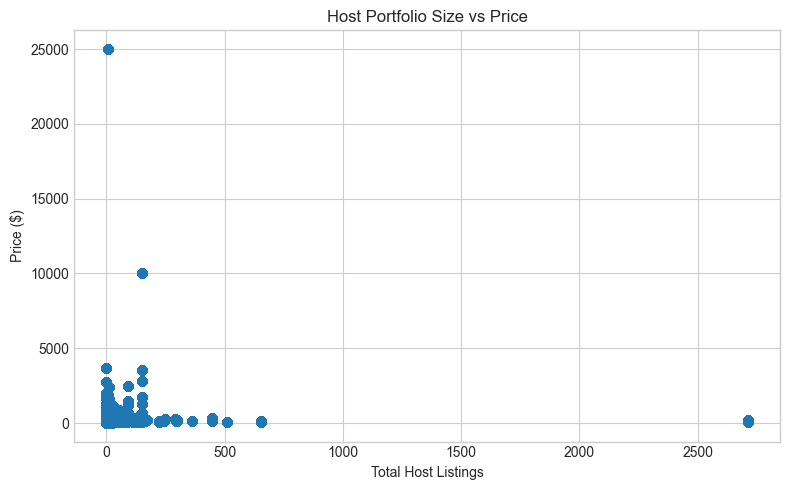

In [30]:
#Does Host Experience (Listings Count) Affect Price?
plt.figure(figsize=(8,5))

plt.scatter(df["host_total_listings_count"], 
            df["price"], 
            alpha=0.3)

plt.xlabel("Total Host Listings")
plt.ylabel("Price ($)")
plt.title("Host Portfolio Size vs Price")

plt.tight_layout()
plt.show()

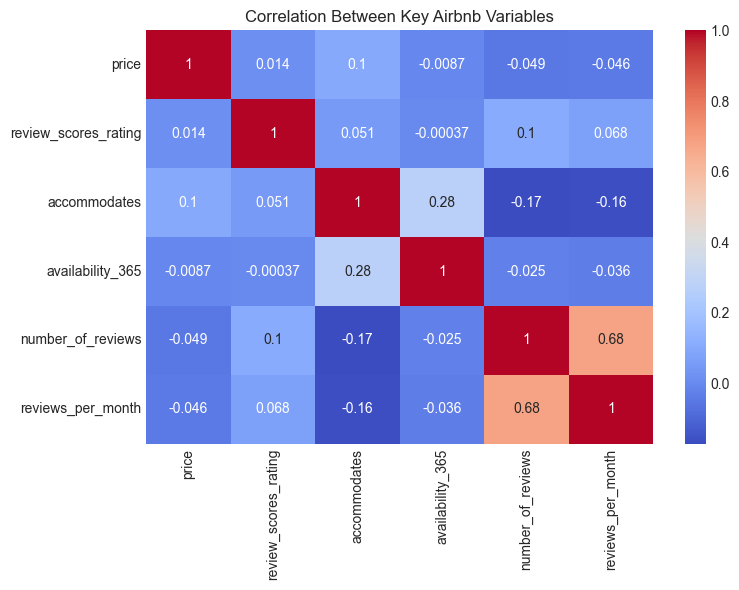

In [31]:
import seaborn as sns

key_cols = [
    "price",
    "review_scores_rating",
    "accommodates",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[key_cols].corr(), 
            annot=True, 
            cmap="coolwarm")

plt.title("Correlation Between Key Airbnb Variables")
plt.tight_layout()
plt.show()

### 6 Model 

### 6.1 Model 1 for predicting price

In [32]:
df_model=df.copy()
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1869716 entries, 0 to 1869715
Columns: 223 entries, listing_id to Room_Type
dtypes: float64(23), int64(191), object(9)
memory usage: 3.1+ GB


In [33]:
df=df_listings.copy()
#df=df.drop(['license', 'calendar_updated', 'bathrooms', 'neighbourhood_group_cleansed', 'bathrooms'], axis=1)
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)


important_features = [
    # Location
    "latitude",
    "longitude",
    "neighbourhood_cleansed",

    # Property characteristics
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms_text",

    # Pricing policy
    "minimum_nights",

    # Demand
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",

    # Host info
    "host_is_superhost",
    "instant_bookable",

    # Target
    "price"
]

df_model = df[important_features].copy()
df_model=df_model.dropna()


df_model["bathrooms"] = (
    df_model["bathrooms_text"]
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

df_model.drop(columns=["bathrooms_text"], inplace=True)

df_model["host_is_superhost"] = df_model["host_is_superhost"].map({
    "t": 1,
    "f": 0
})

df_model["instant_bookable"] = df_model["instant_bookable"].map({
    "t": 1,
    "f": 0
})


cat_cols = [
    "neighbourhood_cleansed",
    "property_type",
    "room_type"
]

df_model["log_price"] = np.log(df_model["price"])




df_model = df_model.drop(['price'], axis=1)



In [34]:
from sklearn.model_selection import train_test_split

target = "log_price"

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42
)

In [35]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

In [37]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Pipeline([
    ("preprocess", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": np.logspace(-3, 3, 20)
}

grid = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie

Best alpha: {'model__alpha': np.float64(112.88378916846884)}
Best CV R²: 0.5840160502063911


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie

In [38]:
best_model = grid.best_estimator_

train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.6280943780109143
Test R²: 0.6075550209381275


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [39]:
y_pred_log = best_model.predict(X_test)
y_pred_price = np.exp(y_pred_log)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


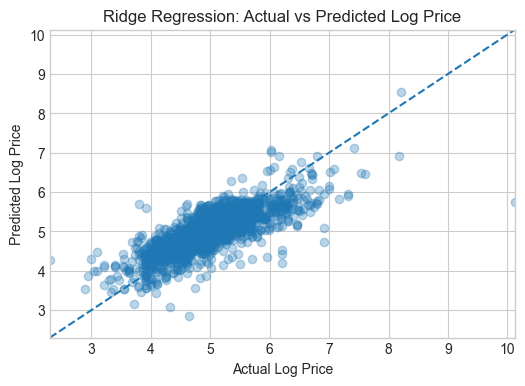

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# predictions
y_pred = best_model.predict(X_test)

# figure
plt.figure(figsize=(6,4))

# scatter plot
plt.scatter(y_test, y_pred, alpha=0.3)

# perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

# labels & title
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Ridge Regression: Actual vs Predicted Log Price")

# equal scaling (VERY important)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.grid(True)
plt.show()

In [41]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

lasso = Pipeline([
    ("preprocess", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", Lasso(max_iter=10000))  # increase iterations for convergence
])

param_grid = {
    "model__alpha": np.logspace(-4, 1, 20)   # smaller range works better for Lasso
}

grid_lasso = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Best alpha:", grid_lasso.best_params_)
print("Best CV R²:", grid_lasso.best_score_)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie

Best alpha: {'model__alpha': np.float64(0.00379269019073225)}
Best CV R²: 0.5838730141860704


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categorie

In [42]:
best_lasso = grid_lasso.best_estimator_

print("Train R²:", best_lasso.score(X_train, y_train))
print("Test R²:", best_lasso.score(X_test, y_test))

Train R²: 0.6260723297563786
Test R²: 0.6093159201345945


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [43]:
model = best_lasso.named_steps["model"]

coef = model.coef_

print("Total features:", len(coef))
print("Selected features:", np.sum(coef != 0))
print("Removed features:", np.sum(coef == 0))

Total features: 93
Selected features: 74
Removed features: 19


In [44]:
feature_names = best_lasso.named_steps["preprocess"].get_feature_names_out()

selected_features = feature_names[coef != 0]
selected_features[:20]

array(['num__longitude', 'num__accommodates', 'num__bedrooms',
       'num__beds', 'num__minimum_nights', 'num__availability_365',
       'num__number_of_reviews', 'num__reviews_per_month',
       'num__host_is_superhost', 'num__bathrooms',
       'cat__neighbourhood_cleansed_District 11',
       'cat__neighbourhood_cleansed_District 12',
       'cat__neighbourhood_cleansed_District 13',
       'cat__neighbourhood_cleansed_District 14',
       'cat__neighbourhood_cleansed_District 15',
       'cat__neighbourhood_cleansed_District 16',
       'cat__neighbourhood_cleansed_District 17',
       'cat__neighbourhood_cleansed_District 18',
       'cat__neighbourhood_cleansed_District 19',
       'cat__neighbourhood_cleansed_District 22'], dtype=object)

In [45]:
y_pred_log = best_model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [46]:
comparison_log = pd.DataFrame({
    "Actual_Log_Price": y_test.values,
    "Predicted_Log_Price": y_pred_log
})

comparison_log.head(10)

,Actual_Log_Price,Predicted_Log_Price
0,5.159055,5.414012
1,5.700444,5.000790
2,4.094345,4.601725
3,5.641907,5.658553
4,5.480639,5.504175
5,4.672829,4.478682
6,6.335054,6.037617
7,5.181784,5.466714
8,5.579730,5.697659
9,5.955837,6.533871


In [47]:
comparison_price = pd.DataFrame({
    "Actual_Price": np.exp(y_test.values),
    "Predicted_Price": np.exp(y_pred_log)
})

comparison_price.head(10)

,Actual_Price,Predicted_Price
0,174.0,224.530709
1,299.0,148.530505
2,60.0,99.656065
3,282.0,286.733307
4,240.0,245.715591
5,107.0,88.118441
6,564.0,418.893669
7,178.0,236.681286
8,265.0,298.168637
9,386.0,688.056331


In [48]:
comparison_price["Absolute_Error"] = (
    comparison_price["Actual_Price"] - comparison_price["Predicted_Price"]
).abs()

comparison_price["Percent_Error"] = (
    comparison_price["Absolute_Error"] / comparison_price["Actual_Price"]
) * 100

comparison_price.head(10)

,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error
0,174.0,224.530709,50.530709,29.040637
1,299.0,148.530505,150.469495,50.324246
2,60.0,99.656065,39.656065,66.093442
3,282.0,286.733307,4.733307,1.678478
4,240.0,245.715591,5.715591,2.381496
5,107.0,88.118441,18.881559,17.646317
6,564.0,418.893669,145.106331,25.728073
7,178.0,236.681286,58.681286,32.967015
8,265.0,298.168637,33.168637,12.516467
9,386.0,688.056331,302.056331,78.252936


In [49]:
comparison_price.sort_values("Percent_Error", ascending=False).head(10)

,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error
1515,10.0,71.353942,61.353942,613.539421
459,45.0,295.295977,250.295977,556.213283
292,50.0,268.563371,218.563371,437.126742
1623,22.0,87.117595,65.117595,295.989068
771,20.0,74.176197,54.176197,270.880986
1026,45.0,133.358577,88.358577,196.352394
1483,100.0,296.018987,196.018987,196.018987
1390,99.0,285.448237,186.448237,188.331552
1310,411.0,1177.414110,766.414110,186.475453
1379,47.0,134.061762,87.061762,185.237791


In [50]:
import numpy as np
import pandas as pd

# Predictions (log scale)
y_pred_log = best_model.predict(X_test)

# Build final table in original price scale
final_table = pd.DataFrame({
    "Actual_Price": np.exp(y_test.values),
    "Predicted_Price": np.exp(y_pred_log)
})

# Add error columns
final_table["Absolute_Error"] = (
    final_table["Actual_Price"] - final_table["Predicted_Price"]
).abs()

final_table["Percent_Error_%"] = (
    final_table["Absolute_Error"] / final_table["Actual_Price"]
) * 100

# Round for cleaner presentation
final_table = final_table.round(2)

# Reset index for clean display
final_table = final_table.reset_index(drop=True)

# Show first 15 rows
final_table.head(15)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Actual_Price,Predicted_Price,Absolute_Error,Percent_Error_%
0,174.0,224.53,50.53,29.04
1,299.0,148.53,150.47,50.32
2,60.0,99.66,39.66,66.09
3,282.0,286.73,4.73,1.68
4,240.0,245.72,5.72,2.38
5,107.0,88.12,18.88,17.65
6,564.0,418.89,145.11,25.73
7,178.0,236.68,58.68,32.97
8,265.0,298.17,33.17,12.52
9,386.0,688.06,302.06,78.25


### Model 2: Booking predcition

In [51]:
df_cal_listings.info(max_cols=225)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1869716 entries, 0 to 1869715
Data columns (total 222 columns):
 #    Column                                        Dtype  
---   ------                                        -----  
 0    listing_id                                    int64  
 1    name                                          object 
 2    description                                   object 
 3    host_id                                       int64  
 4    host_name                                     object 
 5    host_since                                    float64
 6    host_response_rate                            object 
 7    host_acceptance_rate                          object 
 8    host_is_superhost                             int64  
 9    host_neighbourhood                            object 
 10   host_listings_count                           float64
 11   host_total_listings_count                     float64
 12   host_has_profile_pic                    

In [53]:
df_cal_listings['cal_available'].head(20)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     1
10    1
11    1
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
Name: cal_available, dtype: int64

In [54]:
features = [
    # price
    "price",

    # property characteristics
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",

    # location
    "latitude",
    "longitude",

    # room type dummies
    "room_Entire home/apt",
    "room_Private room",
    "room_Shared room",
    "room_Hotel room",

    # review scores
    "review_scores_rating",
    "review_scores_location",

    # host quality
    "host_is_superhost",
    "instant_bookable",

    # time features
    "weekday_Monday",
    "weekday_Tuesday",
    "weekday_Wednesday",
    "weekday_Thursday",
    "weekday_Friday",
    "weekday_Saturday",
    "weekday_Sunday",

    "month_1","month_2","month_3","month_4",
    "month_5","month_6","month_7","month_8",
    "month_9","month_10","month_11","month_12",

    # amenities (luxury signals)
    "am_Pool",
    "am_Hottub",
    "am_Gym",
    "am_Freeparkingonpremises",
]

In [55]:
df_cal_listings["is_booked"] = (df_cal_listings["cal_available"] == 0).astype(int)

In [58]:
df_cls = df_cal_listings[features + ["is_booked"]].copy()
df_cls = df_cls.dropna()

In [62]:
df_cls['is_booked'].head(20) 

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     0
10    0
11    0
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
Name: is_booked, dtype: int64

In [63]:
df_cls .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1869716 entries, 0 to 1869715
Data columns (total 39 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   price                     float64
 1   accommodates              int64  
 2   bedrooms                  float64
 3   beds                      float64
 4   bathrooms                 float64
 5   latitude                  float64
 6   longitude                 float64
 7   room_Entire home/apt      int64  
 8   room_Private room         int64  
 9   room_Shared room          int64  
 10  room_Hotel room           int64  
 11  review_scores_rating      float64
 12  review_scores_location    float64
 13  host_is_superhost         int64  
 14  instant_bookable          int64  
 15  weekday_Monday            int64  
 16  weekday_Tuesday           int64  
 17  weekday_Wednesday         int64  
 18  weekday_Thursday          int64  
 19  weekday_Friday            int64  
 20  weekday_Saturday        

In [64]:
df_sample = df_cls.sample(300000, random_state=42)

X = df_sample.drop(columns=["is_booked"])
y = df_sample["is_booked"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [66]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

Accuracy: 0.6219333333333333
ROC AUC: 0.6639343297756254
              precision    recall  f1-score   support

           0       0.63      0.68      0.66     31812
           1       0.61      0.56      0.58     28188

    accuracy                           0.62     60000
   macro avg       0.62      0.62      0.62     60000
weighted avg       0.62      0.62      0.62     60000



In [67]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred_rf = model.predict(X_test)
y_prob_rf = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6219333333333333
ROC AUC: 0.6639343297756254
              precision    recall  f1-score   support

           0       0.63      0.68      0.66     31812
           1       0.61      0.56      0.58     28188

    accuracy                           0.62     60000
   macro avg       0.62      0.62      0.62     60000
weighted avg       0.62      0.62      0.62     60000



In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# Train RF
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.81475
RF ROC AUC: 0.8907636466384539

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83     31812
           1       0.81      0.79      0.80     28188

    accuracy                           0.81     60000
   macro avg       0.81      0.81      0.81     60000
weighted avg       0.81      0.81      0.81     60000

Confusion Matrix:

[[26691  5121]
 [ 5994 22194]]


iteration 6 done. Accuracy = 0.6419333333333334
iteration 8 done. Accuracy = 0.67495
iteration 10 done. Accuracy = 0.7138666666666666
iteration 12 done. Accuracy = 0.75345
iteration 14 done. Accuracy = 0.7964
iteration 16 done. Accuracy = 0.8287166666666667
iteration 17 done. Accuracy = 0.8442166666666666
iteration 18 done. Accuracy = 0.8561833333333333
iteration 19 done. Accuracy = 0.86775
iteration 20 done. Accuracy = 0.87765
iteration 21 done. Accuracy = 0.8855666666666666
iteration 22 done. Accuracy = 0.8911833333333333
iteration 23 done. Accuracy = 0.8964333333333333
iteration 30 done. Accuracy = 0.90745


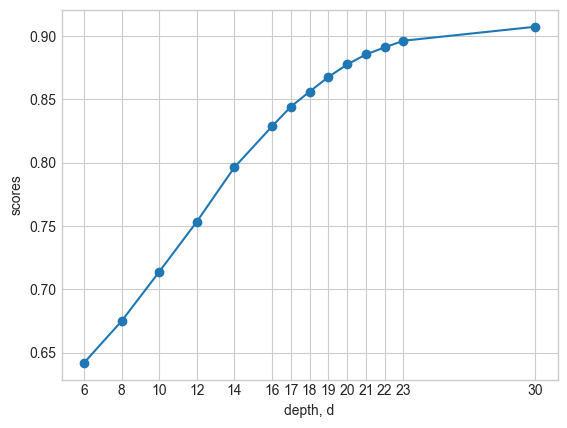

In [69]:
# depth = range(6, 25)

#chose depth
depth = [6, 8, 10, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 30]

# Creates an empty list
scores = []

for d in depth:
    classifier = RandomForestClassifier(max_depth=d, random_state=21)
    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(depth, scores, '-o')
plt.xlabel('depth, d')
plt.ylabel('scores')
plt.xticks(depth)
plt.show()

iteration 31 done. Accuracy = 0.90755
iteration 35 done. Accuracy = 0.9081833333333333
iteration 40 done. Accuracy = 0.90745


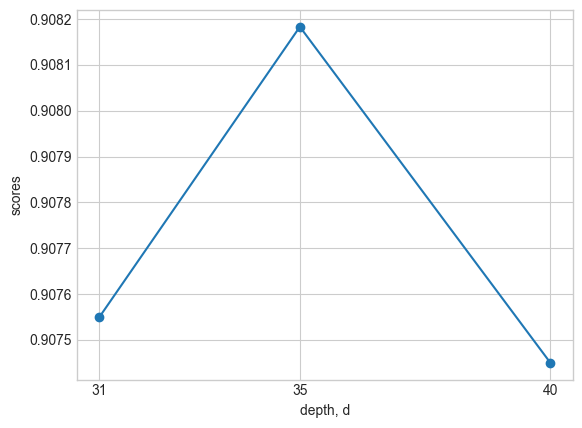

In [70]:
# Searching for best accuracy

#chose depth
depth = [31, 35, 40]

# Creates an empty list
scores = []

for d in depth:
    classifier = RandomForestClassifier(max_depth=d, random_state=21)
    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(depth, scores, '-o')
plt.xlabel('depth, d')
plt.ylabel('scores')
plt.xticks(depth)
plt.show()

iteration 36 done. Accuracy = 0.9085833333333333
iteration 37 done. Accuracy = 0.9070666666666667
iteration 38 done. Accuracy = 0.9072666666666667
iteration 39 done. Accuracy = 0.9073


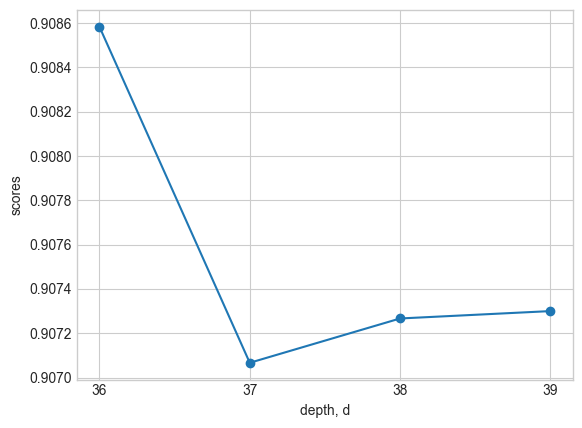

In [71]:
# Searching for best accuracy

#chose depth
depth = [36,37,38,39]

# Creates an empty list
scores = []

for d in depth:
    classifier = RandomForestClassifier(max_depth=d, random_state=21)
    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(depth, scores, '-o')
plt.xlabel('depth, d')
plt.ylabel('scores')
plt.xticks(depth)
plt.show()

- For best decession model

In [72]:
def shorttraintest(vartrain, vartest, Y_train, Y_test, model):

    # Fit the model
    model.fit(vartrain, Y_train)

    # Predict
    model_pred = model.predict(vartest)
    model_prob = model.predict_proba(vartest)

    print('Confusion Matrix:')
    print(confusion_matrix(Y_test, model_pred))
    print("")

    # Accuracy
    score = model.score(vartest, Y_test)
    score_format = 'Accuracy Score: {0:.4f}'.format(score)
    print(score_format)

    # Recall
    recall = recall_score(Y_test, model_pred)
    recall_format = 'Recall Score: {0:.4f}'.format(recall)
    print(recall_format)

    # Precision
    precision = precision_score(Y_test, model_pred)
    precision_format = 'Precision Score: {0:.4f}'.format(precision)
    print(precision_format)

    # ROC Curve
    y_pred_prob = model.predict_proba(vartest)[:, 1]

    fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
    roc_auc = roc_auc_score(Y_test, y_pred_prob)

    roc_auc_format = 'ROC AUC Score: {0:.4f}'.format(roc_auc)
    print(roc_auc_format)
    print('')

In [73]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
def modeltraintest(vartrain, vartest, Y_train, Y_test, model):

    # 1) Fit the model with training data
    model.fit(vartrain, Y_train)

    # 2) Predict using test data
    model_pred = model.predict(vartest)
    model_prob = model.predict_proba(vartest)

    # 3) Accuracy
    score = model.score(vartest, Y_test)

    print('XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX')
    print(round(score, 6))
    print("")

    # 4) Confusion Matrix
    print('XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX')
    print(confusion_matrix(Y_test, model_pred))
    print("")

    # 5) Classification Report
    print('XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX')
    print(classification_report(Y_test, model_pred))
    print('')

    # 6) ROC + AUC
    print('XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX')
    print('')

    y_pred_prob = model.predict_proba(vartest)[:, 1]

    fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
    roc_auc = roc_auc_score(Y_test, y_pred_prob)

    print("ROC AUC Score:", roc_auc)

In [74]:
cw = [
    None,
    'balanced',
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    {0: 1, 1: 10},
    {0: 1, 1: 20},
    {0: 1, 1: 25},
    {0: 1, 1: 30},
    {0: 1, 1: 50},
    {0: 1, 1: 100}
]

vartrain = X_train
vartest = X_test

for w in cw:
    print('-----------------------')

    vartitle = "Model with Class Weight: " + str(w)
    varcw = w

    model = RandomForestClassifier(
        max_depth=36,
        n_estimators=200,
        class_weight=varcw
    )

    print(vartitle)
    print('')

    modeltraintest(vartrain, vartest, y_train, y_test, model)

print('-----------------------')

-----------------------
Model with Class Weight: None

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.908217

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[29518  2294]
 [ 3213 24975]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     31812
           1       0.92      0.89      0.90     28188

    accuracy                           0.91     60000
   macro avg       0.91      0.91      0.91     60000
weighted avg       0.91      0.91      0.91     60000


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.9589914838160428
-----------------------
Model with Class Weight: balanced

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.908233

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[29464  2348]
 [ 3158 25030]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0  

In [69]:
# Class weight none is best for decession model because it is almost balaned. 

In [70]:
#finally we tune max_features

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=36,
    min_samples_leaf=5,      
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

param_grid = {
    "max_features": ["sqrt"]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best max_features:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best max_features: {'max_features': 'sqrt'}
Best CV Accuracy: 0.8815125


In [76]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=36,
    min_samples_leaf=5,      
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

param_grid = {
    "max_features": ["log2"]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best max_features:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best max_features: {'max_features': 'log2'}
Best CV Accuracy: 0.8737291666666668


In [77]:


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=36,
    min_samples_leaf=5,      
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

param_grid = {
    "max_features": [0.2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best max_features:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best max_features: {'max_features': 0.2}
Best CV Accuracy: 0.8849333333333333


In [78]:


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=36,
    min_samples_leaf=5,      
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

param_grid = {
    "max_features": [0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best max_features:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best max_features: {'max_features': 0.5}
Best CV Accuracy: 0.8986083333333333


In [79]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=36,
    min_samples_leaf=5,      
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

param_grid = {
    "max_features": [None]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="accuracy",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best max_features:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best max_features: {'max_features': None}
Best CV Accuracy: 0.8965708333333333


In [80]:
#final model

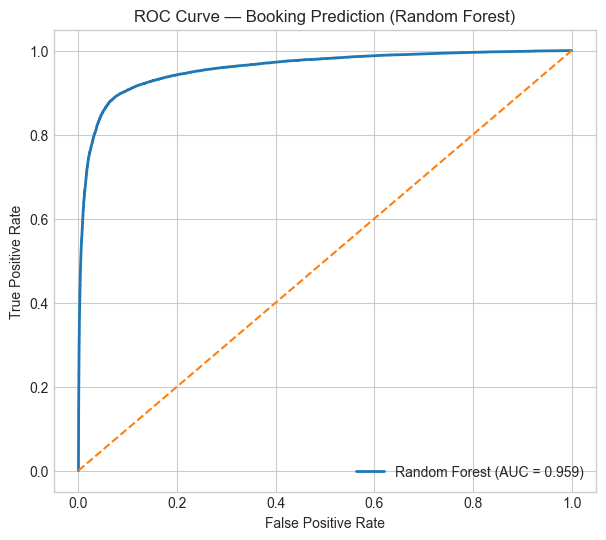

ROC AUC Score: 0.9589009535471369


In [81]:

# Train model
model = RandomForestClassifier(
    max_depth=36,
    n_estimators=200,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(7,6))

plt.plot(
    fpr, tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

# Random baseline
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Booking Prediction (Random Forest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("ROC AUC Score:", roc_auc)

In [82]:
# Predicted class
y_pred = model.predict(X_test)

# Predicted probability
y_prob = model.predict_proba(X_test)[:,1]

In [83]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual_is_booked": y_test.values,
    "Predicted_is_booked": y_pred,
    "Predicted_Probability": y_prob
})

results_df.head(20)

,Actual_is_booked,Predicted_is_booked,Predicted_Probability
0,0,0,0.442637
1,0,0,0.135000
2,1,1,0.865000
3,0,0,0.307500
4,1,1,0.919531
5,1,1,0.809157
6,0,1,0.545000
7,1,1,0.940000
8,1,1,0.883722
9,1,1,0.995000
